In [19]:
import numpy as np
import matplotlib.pyplot as plt

[2 6 3 8 2 4 2 6 4 8]
Attention : Convergence non atteinte après 5000 itérations.
minimum de f1 en x = -0.450 après 659 itérations
minimum de f2 en x = [0.99999951 1.        ] après 753 itérations
minimum de f3 en x = [0.99999888 0.99999772] après 3276 itérations
minimum de f4 en x = [2.00461736 1.99805999] après 5000 itérations
minimum de f5 en x = [4.94612391e-07 2.68157365e-13 1.74741080e-20 4.31841105e-27
 7.00873442e-35 6.27353204e-42 9.51401391e-50 5.76041344e-57
 5.05697535e-65 8.50844492e-73] après 753 itérations


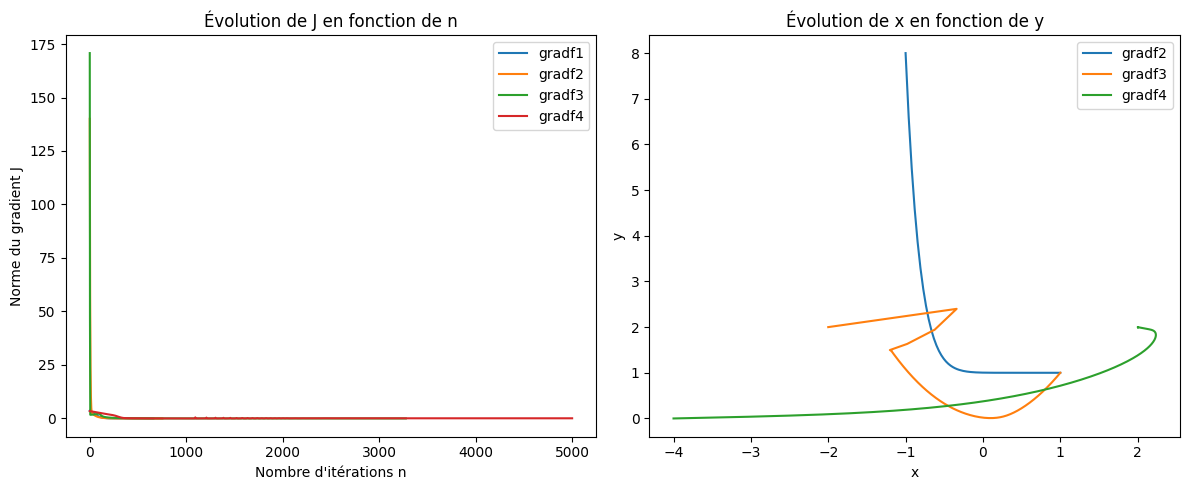

In [20]:
def descente_gradient(x0,gradf,rho = 0.01, eps = 1e-6, Nmax = 5000):
    x = np.array(x0, dtype=float)
    n = 0
    LJ = [np.linalg.norm(gradf(x))]
    LX = [x.copy()]
    while LJ[-1] > eps and n < Nmax:
        x -= rho * gradf(x)
        n += 1
        LJ.append(np.linalg.norm(gradf(x)))
        LX.append(x.copy())
    if n == Nmax:
        print("Attention : Convergence non atteinte après", Nmax, "itérations.")
    return x, n, LJ, np.array(LX)


def f1(X) :
    return X**2 + np.sin(X)

def gradf1(x):
    return 2*x + np.cos(x)

def f2(X):
    return (X[0]-1)**2 + 10*(X[1] - 1)**2

def gradf2(X):
    df1 = 2*X[0] - 2
    df2 = 20*X[1] - 20
    grad = np.array([df1,df2])
    return grad

def f3(X):
    return (X[0]-1)**2 + 10*(X[0]**2 - X[1])**2

def gradf3(X):
    df1 = 40*X[0]**3 - 40*X[1]*X[0] + 2*X[0] - 2
    df2 = 20*X[1] - 20*X[0]**2 
    grad = np.array([df1,df2])
    return grad

def gradf4(X):
    diff = X - A  # Vecteurs x - A_i
    norms = np.linalg.norm(diff, axis=1, keepdims=True)  # ||x - A_i||
    grad = np.sum(diff / norms, axis=0)  # Somme des gradients individuels
    return grad

def f4(X) :
    diff = X - A 
    norms = np.linalg.norm(diff, axis=1, keepdims=True) # ||x - A_i||
    return (np.sum(norms))

def f5(X):
    J = 0
    for i in range(len(X)):
        J += (i+1)*X[i]**2
    return J

def gradf5(X) :
    grad = np.array([2*(i+1)*X[i] for i in range (len(X))])
    return grad

A = np.array([[3.0, 4.0], [5.0, 1.0], [2.0, 2.0],[-1.0,-4.0]])  # Points A_i
X0 = np.random.randint(10, size=10)
print(X0)
res1 = descente_gradient(2,gradf1)
res2 = descente_gradient([-1,8],gradf2)
res3 = descente_gradient([-2,2],gradf3)
res4 = descente_gradient([-4,0],gradf4)
res5 = descente_gradient(X0,gradf5)
print(f'minimum de f1 en x = {res1[0]:.3f} après {res1[1]} itérations')
print(f'minimum de f2 en x = {res2[0]} après {res2[1]} itérations')
print(f'minimum de f3 en x = {res3[0]} après {res3[1]} itérations')
print(f'minimum de f4 en x = {res4[0]} après {res4[1]} itérations')
print(f'minimum de f5 en x = {res5[0]} après {res5[1]} itérations')

# Tracé de J(n)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(res1[2], label='gradf1')
plt.plot(res2[2], label='gradf2')
plt.plot(res3[2], label='gradf3')
plt.plot(res4[2], label='gradf4')
plt.xlabel("Nombre d'itérations n")
plt.ylabel("Norme du gradient J")
plt.title("Évolution de J en fonction de n")
plt.legend()

# Tracé de x(y) pour les fonctions à 2 dimensions
plt.subplot(1, 2, 2)
plt.plot(res2[3][:, 0], res2[3][:, 1], label='gradf2')
plt.plot(res3[3][:, 0], res3[3][:, 1], label='gradf3')
plt.plot(res4[3][:, 0], res4[3][:, 1], label='gradf4')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Évolution de x en fonction de y")
plt.legend()

plt.tight_layout()
plt.show()


Minimum (Descente Gradient Optimal) : [0.09090906 0.63636342] | Itérations : 12
Minimum (Gradient Conjugué) : [0.09090909 0.63636364] | Itérations : 2


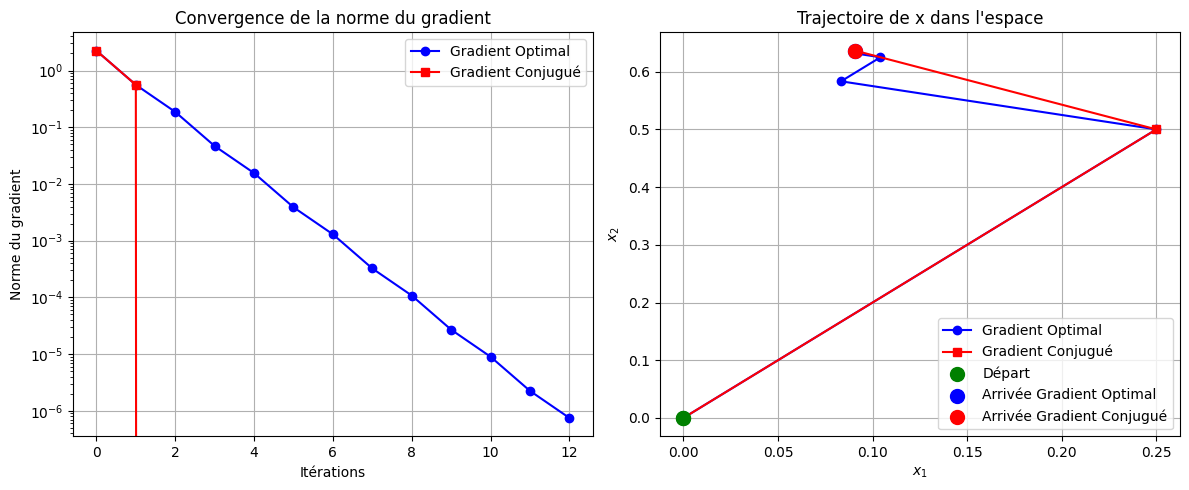

In [21]:
def descente_gradient_quadratique(A, b, x0, eps = 1e-6, Nmax = 5000):
    x = np.array(x0, dtype=float)
    n = 0
    LJ = [np.linalg.norm(A @ x - b)]
    LX = [x.copy()]
    while LJ[-1] > eps and n < Nmax:
        grad = A @ x - b
        rho = pas_optimal(A, b, x)  # Calcul du pas optimal
        x -= rho * grad
        n += 1
        LJ.append(np.linalg.norm(A @ x - b))
        LX.append(x.copy())
    if n == Nmax:
        print("Attention : Convergence non atteinte après", Nmax, "itérations.")
    return x, n, LJ, np.array(LX)

def pas_optimal(A, b, x): # pas_optimal d'une fonction quadratique
    grad = A @ x - b  # Gradient de J(x)
    num = np.dot(grad, grad)  # Norme au carré du gradient
    denom = np.dot(grad, A @ grad)  # Produit quadratique
    return num / denom if denom > 0 else 1e-6  # Évite la division par zéro

def gradient_conjugue(A, b, x0, eps=1e-6, Nmax=5000):
    x = np.array(x0, dtype=float)
    r = b - A @ x   
    p = r         
    n = 0
    LJ = [np.linalg.norm(r)]  
    LX = [x.copy()]  

    while LJ[-1] > eps and n < Nmax:
        Ap = A @ p  
        alpha = np.dot(r, r) / np.dot(p, Ap)  
        x = x + alpha * p  
        r_new = r - alpha * Ap
        beta = np.dot(r_new, r_new) / np.dot(r, r)  
        p = r_new + beta * p 
        r = r_new  
        n += 1
        LJ.append(np.linalg.norm(r))
        LX.append(x.copy())

    return x, n, LJ, np.array(LX)

def J(x):
    Ax = np.dot(A,x)
    scalar1 = np.dot(Ax,x)
    scalar2 = np.dot(b,x)
    return scalar1/2 - scalar2

def gradJ(x):
    Ax = np.dot(A,x)
    return (Ax-b)

# Définition d'une matrice A symétrique définie positive
A = np.array([[4, 1], 
              [1, 3]])

# Définition d'un vecteur b
b = np.array([1, 2])

# Point de départ
x0 = np.array([0, 0])
x_opt, n_opt, LJ_opt, LX_opt = descente_gradient_quadratique(A, b, x0)
x_conj, n_conj, LJ_conj, LX_conj = gradient_conjugue(A, b, x0)

print("Minimum (Descente Gradient Optimal) :", x_opt, "| Itérations :", n_opt)
print("Minimum (Gradient Conjugué) :", x_conj, "| Itérations :", n_conj)

# ---- AFFICHAGE ----
plt.figure(figsize=(12, 5))

# Plot de la norme du gradient
plt.subplot(1, 2, 1)
plt.plot(LJ_opt, marker='o', linestyle='-', color='b', label="Gradient Optimal")
plt.plot(LJ_conj, marker='s', linestyle='-', color='r', label="Gradient Conjugué")
plt.yscale("log")  
plt.xlabel("Itérations")
plt.ylabel("Norme du gradient") 
plt.title("Convergence de la norme du gradient")
plt.legend()
plt.grid()

# Trajectoire dans l'espace des solutions
plt.subplot(1, 2, 2)
plt.plot(LX_opt[:, 0], LX_opt[:, 1], marker='o', linestyle='-', color='b', label="Gradient Optimal")
plt.plot(LX_conj[:, 0], LX_conj[:, 1], marker='s', linestyle='-', color='r', label="Gradient Conjugué")
plt.scatter(LX_opt[0, 0], LX_opt[0, 1], color='g', s=100, label="Départ", zorder=3)
plt.scatter(LX_opt[-1, 0], LX_opt[-1, 1], color='b', s=100, label="Arrivée Gradient Optimal", zorder=3)
plt.scatter(LX_conj[0, 0], LX_conj[0, 1], color='g', s=100, zorder=3)  # Départ aussi pour conjugué
plt.scatter(LX_conj[-1, 0], LX_conj[-1, 1], color='r', s=100, label="Arrivée Gradient Conjugué", zorder=3)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Trajectoire de x dans l'espace")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

Droite ajustée : y = 2.99x + 5.96


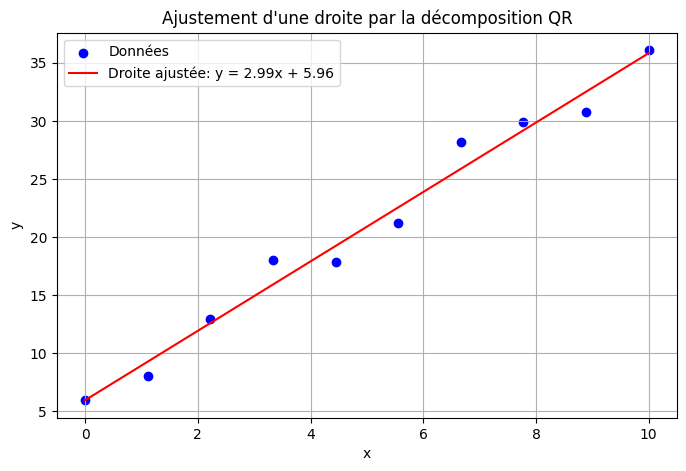

In [22]:
def pb_moindre_affine(X,Y):
    n = len(X)
    A = np.column_stack((X,np.ones(n)))
    Q, R = np.linalg.qr(A)
    theta = np.linalg.solve(R, Q.T @ Y)
    return theta

# --- Exemple ---
np.random.seed(42)
x = np.linspace(0, 10, 10)  
y = 3*x + 5 + np.random.normal(0, 2, len(x))  # y = 3x + 5 avec du bruit
a, b = pb_moindre_affine(x, y)
print(f"Droite ajustée : y = {a:.2f}x + {b:.2f}")


plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue', label="Données")
plt.plot(x, a*x + b, color='red', label=f"Droite ajustée: y = {a:.2f}x + {b:.2f}")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Ajustement d'une droite par la décomposition QR")
plt.legend()
plt.grid()

Courbe ajustée : y = 1.97x² + 2.05x + 4.45


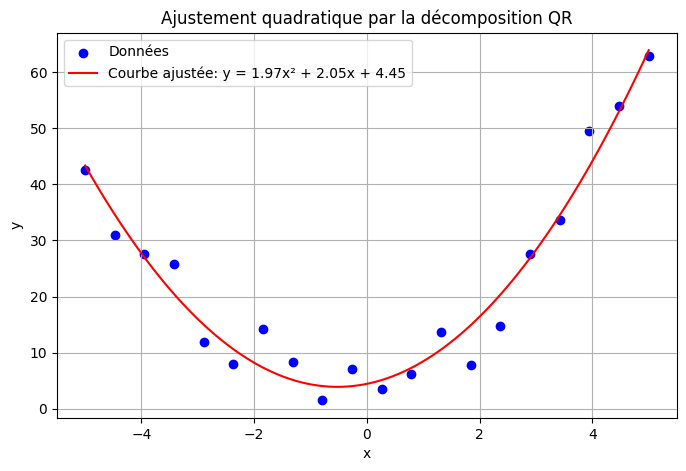

In [23]:
def pb_moindre_quadra(X,Y):
    n = len(X)
    A = np.column_stack((X**2, X, np.ones(n)))
    Q, R = np.linalg.qr(A)
    theta = np.linalg.solve(R, Q.T @ Y)
    return theta

# --- Exemple ---
np.random.seed(42)
x = np.linspace(-5, 5, 20)  
y = 2*x**2 + 3*x + 5 + np.random.normal(0, 5, len(x))  # y = 2x² + 3x + 5 avec du bruit

a, b, c = pb_moindre_quadra(x, y)
print(f"Courbe ajustée : y = {a:.2f}x² + {b:.2f}x + {c:.2f}")

# --- Affichage graphique ---
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue', label="Données")
x_fit = np.linspace(min(x), max(x), 100)
y_fit = a*x_fit**2 + b*x_fit + c
plt.plot(x_fit, y_fit, color='red', label=f"Courbe ajustée: y = {a:.2f}x² + {b:.2f}x + {c:.2f}")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Ajustement quadratique par la décomposition QR")
plt.legend()
plt.grid()
plt.show()